## The Dark Matter of AI
- This code was used for Gemma Walkthrough in this Welch Labs video: https://youtu.be/UGO_Ehywuxc
- Most code borrorowed from these excellent tutorials: https://arena3-chapter1-transformer-interp.streamlit.app/

In [1]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

# Load environment variables from .env file
load_dotenv()

# Login to Hugging Face using token from environment
hf_token = os.getenv('HUGGINGFACE_TOKEN')
if hf_token:
    login(token=hf_token)
    print("✓ Successfully logged into Hugging Face")
else:
    print("⚠️  HUGGINGFACE_TOKEN not found in .env file")
    print("You can still use public models, but private repos won't be accessible")


✓ Successfully logged into Hugging Face


In [2]:
import os
import sys

# Set environment variable for potential library conflicts
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [83]:
from IPython.display import HTML, IFrame, clear_output, display
import random
from rich import print as rprint
from rich.table import Table
from tqdm.auto import tqdm
from functools import partial
import torch as t
import torch.nn.functional as F
from torch import Tensor, nn
from jaxtyping import Float, Int
import einops

import matplotlib.pyplot as plt
import numpy as np

# Enhanced device detection for local environments
def get_device():
    if t.cuda.is_available():
        return t.device("cuda")
    elif hasattr(t.backends, 'mps') and t.backends.mps.is_available():
        return t.device("mps")  # Apple Silicon
    else:
        return t.device("cpu")

device = get_device()
print(f"Using device: {device}")

from sae_lens.toolkit.pretrained_saes_directory import get_pretrained_saes_directory
from sae_lens import (
    SAE,
    ActivationsStore,
    HookedSAETransformer,
    LanguageModelSAERunnerConfig,
    SAEConfig,
    SAETrainingRunner,
    upload_saes_to_huggingface,
)

from transformer_lens import ActivationCache, HookedTransformer, utils
from transformer_lens.hook_points import HookPoint
from tabulate import tabulate

# Replace Google Drive with local file operations
import pickle
import glob
from pathlib import Path

# Optional: Set up local data directory
DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True)

Using device: mps


In [4]:
gemmascope_sae_release = "gemma-scope-2b-pt-mlp-canonical"
gemmascope_sae_id = "layer_20/width_16k/canonical"

In [5]:
gemma_2_2b = HookedSAETransformer.from_pretrained("gemma-2-2b", device=device)

config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Loaded pretrained model gemma-2-2b into HookedTransformer


In [6]:
gemma_2_2b_sae = SAE.from_pretrained(gemmascope_sae_release, gemmascope_sae_id, device=str(device))[0]

params.npz:   0%|          | 0.00/302M [00:00<?, ?B/s]

## Initial data pass through model

In [101]:
prompt = "The reliability of Wikipedia is very"
answer = " high"

In [102]:
utils.test_prompt(prompt, answer, gemma_2_2b)

Tokenized prompt: ['<bos>', 'The', ' reliability', ' of', ' Wikipedia', ' is', ' very']
Tokenized answer: [' high']


Performance on answer token:
Rank: 2        Logit: 25.30 Prob: 11.16% Token: | high|

Top 0th token. Logit: 25.89 Prob: 20.21% Token: | important|
Top 1th token. Logit: 25.41 Prob: 12.50% Token: | much|
Top 2th token. Logit: 25.30 Prob: 11.16% Token: | high|
Top 3th token. Logit: 25.27 Prob: 10.80% Token: | low|
Top 4th token. Logit: 25.14 Prob:  9.48% Token: | questionable|
Top 5th token. Logit: 24.59 Prob:  5.47% Token: | poor|
Top 6th token. Logit: 24.40 Prob:  4.55% Token: | good|
Top 7th token. Logit: 23.56 Prob:  1.96% Token: | well|
Top 8th token. Logit: 23.51 Prob:  1.87% Token: | controversial|
Top 9th token. Logit: 23.24 Prob:  1.42% Token: | often|


Ranks of the answer tokens: [(' high', 2)]

In [103]:
tokens=gemma_2_2b.to_tokens(prompt)
logits, cache = gemma_2_2b.run_with_cache(tokens, remove_batch_dim=True)

In [104]:
logits.shape

torch.Size([1, 7, 256000])

In [108]:
# probs.shape

In [113]:
for i in range(1, 8):
    #Now doing this mapping manually, should match outputs above, just less cool printout, do I need softcap here?
    probs=logits[:,-i,:].softmax(dim=-1)
    token_probs, token_ids = probs[-1, :].topk(1, dim=-1)

    for tk, p in zip(token_ids, token_probs):
        print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))
    #print()

 important 0.2021
 a 0.2196
 is 0.2621
 the 0.432
 of 0.73
  0.2367
<h1> 0.1356


In [10]:
#Now doing this mapping manually, should match outputs above, just less cool printout, do I need softcap here?
probs=logits[:,-1,:].softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)

for tk, p in zip(token_ids, token_probs):
  print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 important 0.2021
 much 0.125
 high 0.1116
 low 0.108
 questionable 0.0948
 poor 0.0547
 good 0.0455
 well 0.0196
 controversial 0.0187
 often 0.0142


## Longer Generation

In [11]:
prompt_2= "The reliability of Wikipedia is very important"

In [12]:
GENERATE_KWARGS = dict(temperature=0.5, freq_penalty=2.0, verbose=False)
gemma_2_2b.generate(prompt_2, max_new_tokens=50, **GENERATE_KWARGS)

'The reliability of Wikipedia is very important. The content on Wikipedia has been proven to have a direct impact on the real world. Therefore, it is essential for the editors to be reliable and trustworthy.\n\nA new study has found that some Wikipedians can be easily manipulated by editors who'

In [13]:
GENERATE_KWARGS = dict(temperature=0.8, freq_penalty=2.0, verbose=False)
gemma_2_2b.generate(prompt_2, max_new_tokens=50, **GENERATE_KWARGS)

'The reliability of Wikipedia is very important for the development of any country. It is the largest source of information in most countries and it is used by millions people worldwide, but there are much less who can explain what makes a reliable source.\n\nIn this article I will show you why Wikipedia'

In [14]:
GENERATE_KWARGS = dict(temperature=0.9, freq_penalty=2.0, verbose=False)
gemma_2_2b.generate(prompt_2, max_new_tokens=50, **GENERATE_KWARGS)

'The reliability of Wikipedia is very important for students, but it isn’t as intuitive to define and evaluate as in other media contexts. In this short article, a set of criteria are explained that users can apply to determine how reliable the information on an article page is.\n\nFirst,'

In [15]:
GENERATE_KWARGS = dict(temperature=1.0, freq_penalty=2.0, verbose=False)
gemma_2_2b.generate(prompt_2, max_new_tokens=50, **GENERATE_KWARGS)

'The reliability of Wikipedia is very important in most domains and more specifically for technical-scientific domains, where facts are continuously updated. Any wrong information can cause a massive impact on computers or any related devices and systems operations performance getting even them offline, especially when this erroneous info is published by well'

## Next Token and Longer Generation with Instruction Tuned Gemma

In [16]:
gemma_2_2b_it = HookedSAETransformer.from_pretrained("gemma-2-2b-it", device=device)

config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/241M [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Loaded pretrained model gemma-2-2b-it into HookedTransformer


In [17]:
utils.test_prompt(prompt, answer, gemma_2_2b_it)

Tokenized prompt: ['<bos>', 'The', ' reliability', ' of', ' Wikipedia', ' is', ' very']
Tokenized answer: [' high']


Performance on answer token:
Rank: 5        Logit: 13.61 Prob:  2.64% Token: | high|

Top 0th token. Logit: 16.39 Prob: 42.28% Token: | much|
Top 1th token. Logit: 15.32 Prob: 14.62% Token: | important|
Top 2th token. Logit: 14.39 Prob:  5.74% Token: | often|
Top 3th token. Logit: 14.17 Prob:  4.63% Token: | controversial|
Top 4th token. Logit: 14.11 Prob:  4.33% Token: | debatable|
Top 5th token. Logit: 13.61 Prob:  2.64% Token: | high|
Top 6th token. Logit: 13.59 Prob:  2.59% Token: | questionable|
Top 7th token. Logit: 13.49 Prob:  2.34% Token: | debated|
Top 8th token. Logit: 12.91 Prob:  1.31% Token: | complex|
Top 9th token. Logit: 12.80 Prob:  1.17% Token: | low|


Ranks of the answer tokens: [(' high', 5)]

In [18]:
GENERATE_KWARGS = dict(temperature=0.5, freq_penalty=2.0, verbose=False)
gemma_2_2b.generate("The reliability of Wikipedia is very important", max_new_tokens=50, **GENERATE_KWARGS)

'The reliability of Wikipedia is very important. The quality of the information and its accuracy are essential for users to find reliable information on Wikipedia.\n\nWikipedia has several tools that can help improve the reliability of articles, such as:\n\n* <strong>Community guidelines</strong>: Wikipedia has a set of'

In [19]:
gemma_2_2b.generate("The reliability of Wikipedia is very much", max_new_tokens=50, **GENERATE_KWARGS)

"The reliability of Wikipedia is very much in doubt. Its articles are often poorly researched, written by amateurs and/or vandals, and it's not even clear that the information in its articles is correct.\n\nNevertheless, there are some good things about Wikipedia:\n\n* It'"

## Visualize Data Moving Through model

In [20]:
prompt = "The reliability of Wikipedia is very"

In [21]:
tokens=gemma_2_2b.to_tokens(prompt)
logits, cache = gemma_2_2b.run_with_cache(tokens, remove_batch_dim=True)

In [22]:
cache['hook_embed'].shape

torch.Size([7, 2304])

In [23]:
t.testing.assert_close(cache['hook_embed'], cache['blocks.0.hook_resid_pre'])

In [24]:
m=cache['hook_embed'].detach().cpu().numpy()[-1,:]

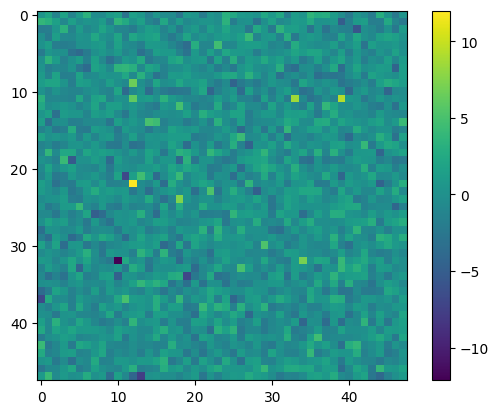

In [25]:
plt.imshow(m.reshape(48,48)); plt.colorbar()

In [26]:
activations_norm_ln_final=gemma_2_2b.ln_final(cache['hook_embed'])

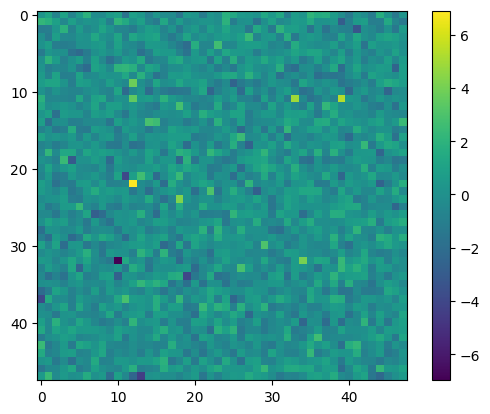

In [27]:
m=activations_norm_ln_final.detach().cpu().numpy()[-1,:]
plt.imshow(m.reshape(48,48)); plt.colorbar()

In [28]:
my_logits = gemma_2_2b.unembed(activations_norm_ln_final)
my_logits_softcap = gemma_2_2b.cfg.output_logits_soft_cap * F.tanh(my_logits / gemma_2_2b.cfg.output_logits_soft_cap)
# my_logits_softcap=my_logits

probs=my_logits_softcap.softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
for tk, p in zip(token_ids, token_probs):
  print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 very 0.006
very 0.006
 Very 0.006
Very 0.006
 VERY 0.006
 très 0.006
 muy 0.006
VERY 0.006
 extremely 0.006
 sehr 0.0059


In [29]:
my_logits = gemma_2_2b.unembed(activations_norm_ln_final)
# my_logits_softcap = gemma_2_2b.cfg.output_logits_soft_cap * F.tanh(my_logits / gemma_2_2b.cfg.output_logits_soft_cap)
my_logits_softcap=my_logits

probs=my_logits_softcap.softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
for tk, p in zip(token_ids, token_probs):
  print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 very 1.0
very 0.0
 Very 0.0
Very 0.0
<pad> 0.0
<eos> 0.0
<bos> 0.0
<unk> 0.0
<mask> 0.0
<2mass> 0.0


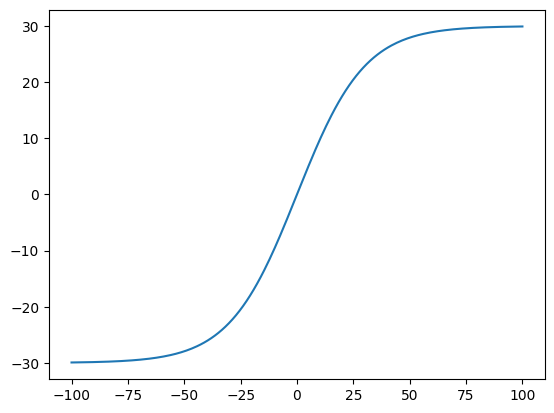

In [30]:
#Softcapping
xs=t.tensor(np.linspace(-100, 100, 256))
ys=gemma_2_2b.cfg.output_logits_soft_cap * F.tanh(xs / gemma_2_2b.cfg.output_logits_soft_cap)
plt.plot(xs,ys)

Ok so basically capped at +/- 30.

## First Attention Block

In [31]:
t.testing.assert_close(cache['hook_embed']+cache['blocks.0.hook_attn_out'], cache['blocks.0.hook_resid_mid'])

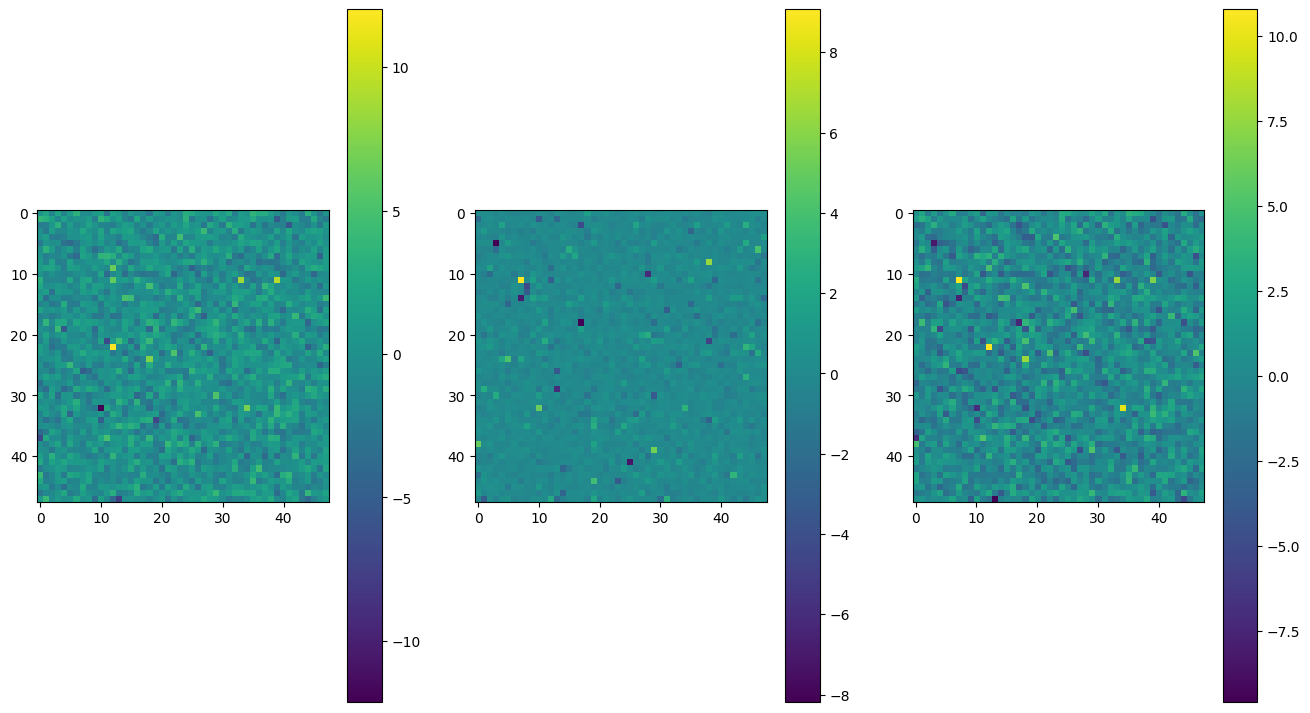

In [32]:
fig=plt.figure(0, (16,9))
fig.add_subplot(1,3,1)
m=cache['hook_embed'].detach().cpu().numpy()[-1,:]
plt.imshow(m.reshape(48,48)); plt.colorbar()

fig.add_subplot(1,3,2)
m=cache['blocks.0.hook_attn_out'].detach().cpu().numpy()[-1,:]
plt.imshow(m.reshape(48,48)); plt.colorbar()

fig.add_subplot(1,3,3)
m=cache['blocks.0.hook_resid_mid'].detach().cpu().numpy()[-1,:]
plt.imshow(m.reshape(48,48)); plt.colorbar()

In [33]:
activations_norm_ln_final=gemma_2_2b.ln_final(cache['blocks.0.hook_attn_out'])
my_logits = gemma_2_2b.unembed(activations_norm_ln_final)
my_logits_softcap = gemma_2_2b.cfg.output_logits_soft_cap * F.tanh(my_logits / gemma_2_2b.cfg.output_logits_soft_cap)
# my_logits_softcap=my_logits

probs=my_logits_softcap.softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
for tk, p in zip(token_ids, token_probs):
  print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 myſelf 0.0001
 itſelf 0.0001
 Efq 0.0001
 Monfieur 0.0001
 ――――― 0.0001
ſelf 0.0001
 ་་ 0.0001
 Jefus 0.0001
ſelves 0.0001
 pleaſure 0.0001


In [34]:
activations_norm_ln_final=gemma_2_2b.ln_final(cache['blocks.0.hook_resid_mid'])
my_logits = gemma_2_2b.unembed(activations_norm_ln_final)
my_logits_softcap = gemma_2_2b.cfg.output_logits_soft_cap * F.tanh(my_logits / gemma_2_2b.cfg.output_logits_soft_cap)
# my_logits_softcap=my_logits

probs=my_logits_softcap.softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
for tk, p in zip(token_ids, token_probs):
  print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 very 0.0117
very 0.0117
Very 0.0117
 Very 0.0117
 VERY 0.0117
VERY 0.0117
 très 0.0117
 muy 0.0117
 sehr 0.0116
 extremely 0.0115


## Layer 1 MLP


In [35]:
t.testing.assert_close(cache['blocks.0.hook_resid_mid']+cache['blocks.0.hook_mlp_out'], cache['blocks.0.hook_resid_post'])

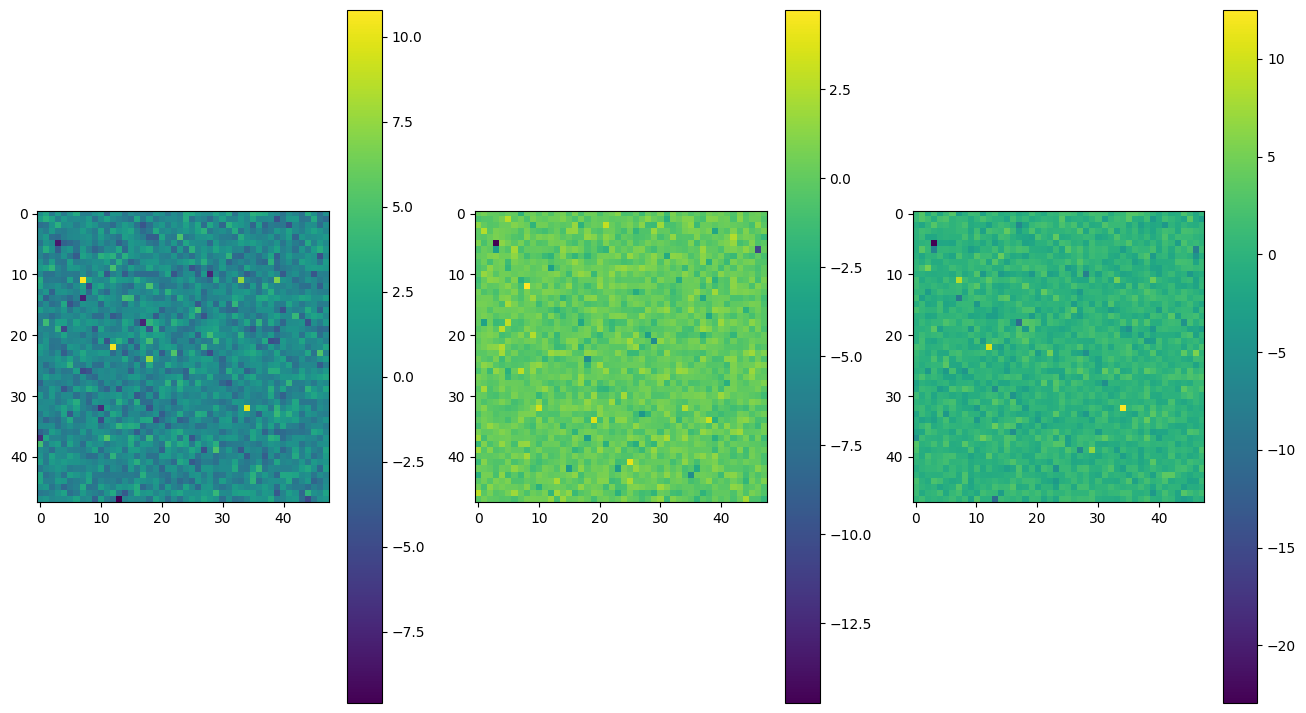

In [36]:
fig=plt.figure(0, (16,9))
fig.add_subplot(1,3,1)
m=cache['blocks.0.hook_resid_mid'].detach().cpu().numpy()[-1,:]
plt.imshow(m.reshape(48,48)); plt.colorbar()

fig.add_subplot(1,3,2)
m=cache['blocks.0.hook_mlp_out'].detach().cpu().numpy()[-1,:]
plt.imshow(m.reshape(48,48)); plt.colorbar()

fig.add_subplot(1,3,3)
m=cache['blocks.0.hook_resid_post'].detach().cpu().numpy()[-1,:]
plt.imshow(m.reshape(48,48)); plt.colorbar()

In [37]:
activations_norm_ln_final=gemma_2_2b.ln_final(cache['blocks.0.hook_resid_post'])
my_logits = gemma_2_2b.unembed(activations_norm_ln_final)
my_logits_softcap = gemma_2_2b.cfg.output_logits_soft_cap * F.tanh(my_logits / gemma_2_2b.cfg.output_logits_soft_cap)
# my_logits_softcap=my_logits

probs=my_logits_softcap.softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
for tk, p in zip(token_ids, token_probs):
  print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 very 0.0161
very 0.0161
Very 0.0161
 Very 0.0161
 VERY 0.016
VERY 0.0159
 très 0.0158
 muy 0.0158
 sehr 0.0154
 extremely 0.0151


## Move Through a bunch of Layers
- will be fun to storyboard this/think about full layout.

In [38]:
tokens=gemma_2_2b.to_tokens(prompt)
logits, cache = gemma_2_2b.run_with_cache(tokens, remove_batch_dim=True)
all_res=[]

for layer_id in range(25):
  activations_norm_next_layer=cache['blocks.'+str(layer_id+1)+'.ln1.hook_normalized']
  # activations_norm_ln_final=gemma_2_2b.ln_final(activations)

  my_logits = gemma_2_2b.unembed(activations_norm_next_layer)
  my_logits_softcap = gemma_2_2b.cfg.output_logits_soft_cap * F.tanh(my_logits / gemma_2_2b.cfg.output_logits_soft_cap)
  # my_logits_softcap=my_logits

  probs=my_logits_softcap.softmax(dim=-1)
  token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
  res={}
  for tk, p in zip(token_ids, token_probs):
    res[gemma_2_2b.to_string(tk.item())] = round(p.item(), 4)
  all_res.append(res)
  # print(layer_id, res)

#Final outputs
probs=logits.softmax(dim=-1)
token_probs, token_ids = probs[0,-1, :].topk(10, dim=-1)
res={}
for tk, p in zip(token_ids, token_probs):
  res[gemma_2_2b.to_string(tk.item())] = round(p.item(), 4)
all_res.append(res)
# print(layer_id+1, res)

## Close Look at 21st Layer (layer 20)

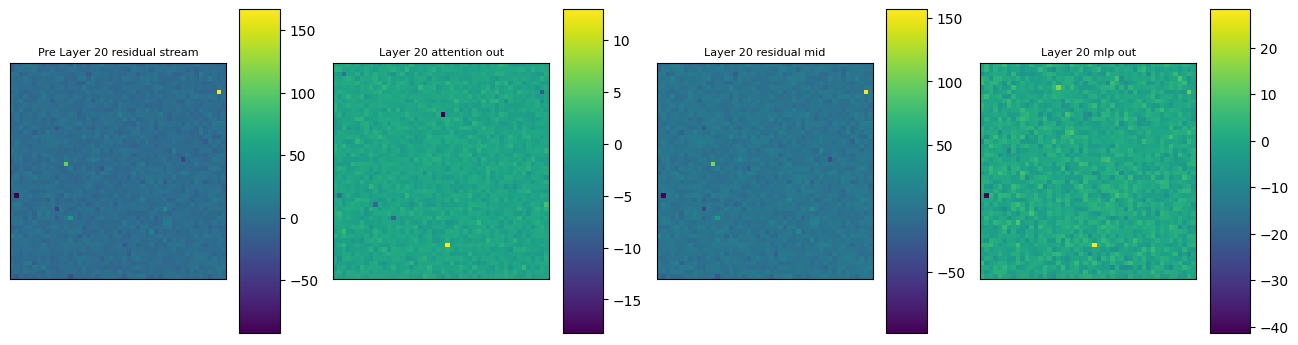

In [39]:
layer_id=20
subplot_rows=1

residual_stream=cache['blocks.'+str(layer_id)+'.hook_resid_pre'].detach().cpu().numpy()
attn_out=cache['blocks.'+str(layer_id)+'.hook_attn_out'].detach().cpu().numpy()
residual_stream_mid=cache['blocks.'+str(layer_id)+'.hook_resid_mid'].detach().cpu().numpy()
mlp_out=cache['blocks.'+str(layer_id)+'.hook_mlp_out'].detach().cpu().numpy()

fig=plt.figure(0, (16,8))
plt.subplot(subplot_rows,4,1); plt.imshow(residual_stream[-1].reshape(48,48)); plt.colorbar(aspect=8); plt.title('Pre Layer '+str(layer_id)+' residual stream', fontsize=8); plt.xticks([]); plt.yticks([]);
plt.subplot(subplot_rows,4,2); plt.imshow(attn_out[-1].reshape(48,48)); plt.colorbar(aspect=8); plt.title('Layer '+str(layer_id)+' attention out', fontsize=8); plt.xticks([]); plt.yticks([]);
plt.subplot(subplot_rows,4,3); plt.imshow(residual_stream_mid[-1].reshape(48,48)); plt.colorbar(aspect=8); plt.title('Layer '+str(layer_id)+' residual mid', fontsize=8); plt.xticks([]); plt.yticks([]);
plt.subplot(subplot_rows,4,4); plt.imshow(mlp_out[-1].reshape(48,48)); plt.colorbar(aspect=8); plt.title('Layer '+str(layer_id)+' mlp out', fontsize=8); plt.xticks([]); plt.yticks([]);

In [40]:
top_indices = np.argsort(np.abs(mlp_out[-1]))[-10:][::-1]
mlp_out[-1][top_indices]

array([-41.351578 ,  28.297209 ,  15.395203 ,  12.390208 , -10.604654 ,
         8.926522 ,  -8.531486 ,   8.488743 ,   8.193386 ,  -8.0729065],
      dtype=float32)

In [41]:
top_indices

array([1393, 1945,  257,  334,  918, 1688,  552,  188,  740,  816])

## Steering on 1393

In [42]:
neuron_index=1393

In [43]:
def scale_hook(value, hook):
  value[:, :, neuron_index] = 1*value[:, :, neuron_index]
  return value

logits = gemma_2_2b.run_with_hooks(tokens, fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)])
probs=logits[:,-1,:].softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
for tk, p in zip(token_ids, token_probs):
  print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 important 0.2021
 much 0.125
 high 0.1116
 low 0.108
 questionable 0.0948
 poor 0.0547
 good 0.0455
 well 0.0196
 controversial 0.0187
 often 0.0142


### Scaling current output value

In [44]:
def scale_hook(value, hook):
  value[:, :, neuron_index] = 10*value[:, :, neuron_index]
  return value

logits = gemma_2_2b.run_with_hooks(tokens, fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)])
probs=logits[:,-1,:].softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
for tk, p in zip(token_ids, token_probs):
  print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 important 0.279
 much 0.1183
 high 0.1109
 good 0.0771
 low 0.0499
 questionable 0.0433
 well 0.0287
 different 0.0173
 controversial 0.0169
 difficult 0.0162


In [45]:
def scale_hook(value, hook):
  value[:, :, neuron_index] = -10*value[:, :, neuron_index]
  return value

logits = gemma_2_2b.run_with_hooks(tokens, fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)])
probs=logits[:,-1,:].softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
for tk, p in zip(token_ids, token_probs):
  print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 much 0.2587
 poor 0.1187
 important 0.1053
 low 0.0815
 questionable 0.0755
 high 0.0417
 good 0.0314
 often 0.0267
, 0.0167
 well 0.0148


Show that other active neurons in this output don't have quite the same effect

In [46]:
neuron_index=1945

In [47]:
def scale_hook(value, hook):
  value[:, :, neuron_index] = 10*value[:, :, neuron_index]
  return value

logits = gemma_2_2b.run_with_hooks(tokens, fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)])
probs=logits[:,-1,:].softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
for tk, p in zip(token_ids, token_probs):
  print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 important 0.1724
 much 0.1518
 high 0.1203
 questionable 0.0768
 good 0.0726
 poor 0.0663
 low 0.0345
 dependent 0.0158
 dubious 0.0154
 well 0.014


In [48]:
def scale_hook(value, hook):
  value[:, :, neuron_index] = -10*value[:, :, neuron_index]
  return value

logits = gemma_2_2b.run_with_hooks(tokens, fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)])
probs=logits[:,-1,:].softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
for tk, p in zip(token_ids, token_probs):
  print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 important 0.2446
 low 0.1259
 much 0.1234
 high 0.0851
 questionable 0.06
 good 0.0423
 often 0.0339
 well 0.0322
 poor 0.0249
 controversial 0.0186


In [49]:
neuron_index=257

In [50]:
def scale_hook(value, hook):
  value[:, :, neuron_index] = 10*value[:, :, neuron_index]
  return value

logits = gemma_2_2b.run_with_hooks(tokens, fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)])
probs=logits[:,-1,:].softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
for tk, p in zip(token_ids, token_probs):
  print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 important 0.2007
 low 0.1658
 high 0.0981
 much 0.093
 questionable 0.0685
 poor 0.0665
 good 0.0295
 controversial 0.0204
 often 0.0171
 well 0.0168


In [51]:
def scale_hook(value, hook):
  value[:, :, neuron_index] = -10*value[:, :, neuron_index]
  return value

logits = gemma_2_2b.run_with_hooks(tokens, fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)])
probs=logits[:,-1,:].softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
for tk, p in zip(token_ids, token_probs):
  print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 much 0.2487
 important 0.1644
 high 0.1012
 questionable 0.0825
 good 0.0566
 low 0.0333
 well 0.0247
 poor 0.0197
 often 0.0163
 dubious 0.016


In [52]:
neuron_index=334

In [53]:
def scale_hook(value, hook):
  value[:, :, neuron_index] = 10*value[:, :, neuron_index]
  return value

logits = gemma_2_2b.run_with_hooks(tokens, fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)])
probs=logits[:,-1,:].softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
for tk, p in zip(token_ids, token_probs):
  print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 important 0.1964
 high 0.1176
 much 0.1176
 low 0.1057
 questionable 0.0917
 good 0.0517
 poor 0.0509
 well 0.0204
 controversial 0.0203
 often 0.0134


In [54]:
def scale_hook(value, hook):
  value[:, :, neuron_index] = -10*value[:, :, neuron_index]
  return value

logits = gemma_2_2b.run_with_hooks(tokens, fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)])
probs=logits[:,-1,:].softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
for tk, p in zip(token_ids, token_probs):
  print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 important 0.2116
 much 0.1412
 low 0.1049
 high 0.0979
 questionable 0.0896
 poor 0.0573
 good 0.0413
 well 0.0196
 controversial 0.0169
 often 0.0158


In [55]:
neuron_index=1393

### Clamping Nueron Value

In [56]:
neuron_index=1393

In [57]:
  def scale_hook(value, hook):
    value[:, :, neuron_index] = -50
    return value

  logits = gemma_2_2b.run_with_hooks(tokens, fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)])
  probs=logits[:,-1,:].softmax(dim=-1)
  token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
  for tk, p in zip(token_ids, token_probs):
    print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 important 0.2034
 much 0.1236
 high 0.1132
 low 0.1072
 questionable 0.0934
 poor 0.0529
 good 0.0463
 well 0.0199
 controversial 0.0189
 often 0.0142


In [58]:
  def scale_hook(value, hook):
    value[:, :, neuron_index] = -80
    return value

  logits = gemma_2_2b.run_with_hooks(tokens, fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)])
  probs=logits[:,-1,:].softmax(dim=-1)
  token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
  for tk, p in zip(token_ids, token_probs):
    print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 important 0.2096
 much 0.1194
 high 0.1177
 low 0.1032
 questionable 0.0889
 good 0.0493
 poor 0.0482
 well 0.0205
 controversial 0.0193
 often 0.014


In [59]:
  def scale_hook(value, hook):
    value[:, :, neuron_index] = -120
    return value

  logits = gemma_2_2b.run_with_hooks(tokens, fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)])
  probs=logits[:,-1,:].softmax(dim=-1)
  token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
  for tk, p in zip(token_ids, token_probs):
    print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 important 0.2178
 high 0.1222
 much 0.1156
 low 0.0971
 questionable 0.0825
 good 0.0533
 poor 0.0422
 well 0.0215
 controversial 0.0196
 often 0.0138


In [60]:
  def scale_hook(value, hook):
    value[:, :, neuron_index] = -160
    return value

  logits = gemma_2_2b.run_with_hooks(tokens, fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)])
  probs=logits[:,-1,:].softmax(dim=-1)
  token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
  for tk, p in zip(token_ids, token_probs):
    print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 important 0.2263
 high 0.125
 much 0.1136
 low 0.0902
 questionable 0.0757
 good 0.0572
 poor 0.0366
 well 0.0226
 controversial 0.0196
 often 0.0138


In [61]:
  def scale_hook(value, hook):
    value[:, :, neuron_index] = 100
    return value

  logits = gemma_2_2b.run_with_hooks(tokens, fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)])
  probs=logits[:,-1,:].softmax(dim=-1)
  token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
  for tk, p in zip(token_ids, token_probs):
    print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 important 0.1672
 much 0.1636
 low 0.1157
 questionable 0.1069
 high 0.082
 poor 0.0782
 good 0.0333
 well 0.0174
 often 0.0167
 controversial 0.0155


In [62]:
  def scale_hook(value, hook):
    value[:, :, neuron_index] = 120
    return value

  logits = gemma_2_2b.run_with_hooks(tokens, fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)])
  probs=logits[:,-1,:].softmax(dim=-1)
  token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
  for tk, p in zip(token_ids, token_probs):
    print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 much 0.1709
 important 0.1617
 low 0.1154
 questionable 0.1072
 poor 0.0817
 high 0.0776
 good 0.032
 often 0.0173
 well 0.0171
 controversial 0.0149


In [63]:
  def scale_hook(value, hook):
    value[:, :, neuron_index] = 160
    return value

  logits = gemma_2_2b.run_with_hooks(tokens, fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)])
  probs=logits[:,-1,:].softmax(dim=-1)
  token_probs, token_ids = probs[-1, :].topk(10, dim=-1)
  for tk, p in zip(token_ids, token_probs):
    print(gemma_2_2b.to_string(tk.item()), round(p.item(), 4))

 much 0.1862
 important 0.151
 low 0.1136
 questionable 0.1066
 poor 0.0887
 high 0.0692
 good 0.0299
 often 0.0186
 well 0.0165
 dependent 0.0142


In [64]:
def generate_with_neuron_steering(
    model: HookedSAETransformer,
    sae: SAE,
    prompt: str,
    neuron_index: int,
    steering_coefficient: float = 1.0,
    max_new_tokens: int = 50,
):
    """
    Generates text with steering. A multiple of the steering vector (the decoder weight for this latent) is added to
    the last sequence position before every forward pass.
    """
    # _steering_hook = partial(
    #     steering_hook,
    #     sae=sae,
    #     latent_idx=latent_idx,
    #     steering_coefficient=steering_coefficient,
    # )

    def scale_hook(value, hook):
      value[:, :, neuron_index] = steering_coefficient*value[:, :, neuron_index]
      return value

    with model.hooks(fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)]):
        output = model.generate(prompt, max_new_tokens=max_new_tokens, **GENERATE_KWARGS)

    return output

In [65]:
generate_with_neuron_steering(gemma_2_2b, gemma_2_2b_sae, prompt, neuron_index=1393, steering_coefficient=10.0)

'The reliability of Wikipedia is very important in the current era of information. The existence of a large number of users who are involved in the process of editing and updating articles on Wikipedia makes it difficult to maintain its reliability. Therefore, we need to find a way to determine the quality and'

In [66]:
generate_with_neuron_steering(gemma_2_2b, gemma_2_2b_sae, prompt, neuron_index=1393, steering_coefficient=10.0)

'The reliability of Wikipedia is very important. I’ve been a contributor for 10 years and I have seen the quality of articles grow. However, there are some issues that need to be addressed.\n\n<h2>What’s wrong with the current system?</h2>\n\nCurrently,'

In [67]:
generate_with_neuron_steering(gemma_2_2b, gemma_2_2b_sae, prompt, neuron_index=1393, steering_coefficient=-10.0)

"The reliability of Wikipedia is very much in question, and the article you linked to is a great example.\n\nIt's an interesting question though, and I'd like to see some good research on this topic. It's not something that I would take lightly, but"

In [68]:
generate_with_neuron_steering(gemma_2_2b, gemma_2_2b_sae, prompt, neuron_index=1393, steering_coefficient=-10.0)

'The reliability of Wikipedia is very much a matter of opinion.\n\nSome people feel it is so reliable that they use it as their only source for information. Others have a very low opinion of the site and feel that any article can be edited by anyone, including malicious or misinformed'

### Generation with Clamped Neuron

In [69]:
def generate_with_neuron_steering(
    model: HookedSAETransformer,
    sae: SAE,
    prompt: str,
    neuron_index: int,
    steering_coefficient: float = 1.0,
    max_new_tokens: int = 50,
):
    """
    Generates text with steering. A multiple of the steering vector (the decoder weight for this latent) is added to
    the last sequence position before every forward pass.
    """
    # _steering_hook = partial(
    #     steering_hook,
    #     sae=sae,
    #     latent_idx=latent_idx,
    #     steering_coefficient=steering_coefficient,
    # )

    def scale_hook(value, hook):
      value[:, :, neuron_index] = steering_coefficient
      return value

    with model.hooks(fwd_hooks=[('blocks.20.hook_mlp_out', scale_hook)]):
        output = model.generate(prompt, max_new_tokens=max_new_tokens, **GENERATE_KWARGS)

    return output

In [70]:
generate_with_neuron_steering(gemma_2_2b, gemma_2_2b_sae, prompt, neuron_index=1393, steering_coefficient=-120.0)

'The reliability of Wikipedia is very much at question. The article about the 1980s and 1990s was written by a person who has been involved in this field for the past 30 years, and I have seen many articles written by people'

In [71]:
generate_with_neuron_steering(gemma_2_2b, gemma_2_2b_sae, prompt, neuron_index=1393, steering_coefficient=-80.0)

'The reliability of Wikipedia is very much in doubt, but it’s still a useful tool for getting started with a new topic.\n\nA few years ago I was interested in learning more about the history of the American West and I decided to start with an article on the Wild West'

In [72]:
generate_with_neuron_steering(gemma_2_2b, gemma_2_2b_sae, prompt, neuron_index=1393, steering_coefficient=120.0)

"The reliability of Wikipedia is very questionable. I don't know if it can be trusted, but the information you provide is very interesting.\n\nThis was a great post! I have been looking for something like this for a while now and am happy to find that you have written"

## Polysemanticity and Superposition

In [73]:
def display_dashboard(
    sae_release="gpt2-small-res-jb",
    sae_id="blocks.7.hook_resid_pre",
    latent_idx=0,
    width=1200,
    height=800,
):
    release = get_pretrained_saes_directory()[sae_release]
    neuronpedia_id = release.neuronpedia_id[sae_id]

    url = f"https://neuronpedia.org/{neuronpedia_id}/{latent_idx}?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300"

    print(url)
    display(IFrame(url, width=width, height=height))

def steering_hook(
    activations: Float[Tensor, "batch pos d_in"],
    hook: HookPoint,
    sae: SAE,
    latent_idx: int,
    steering_coefficient: float,
) -> Tensor:
    """
    Steers the model by returning a modified activations tensor, with some multiple of the steering vector added to all
    sequence positions.
    """
    return activations + steering_coefficient * sae.W_dec[latent_idx] #Hmm wow how can we visualize this - interesting. Pretty simple in a way.


def generate_with_steering( #Ah I could do a version of this for neurons - right!
    model: HookedSAETransformer,
    sae: SAE,
    prompt: str,
    latent_idx: int,
    steering_coefficient: float = 1.0,
    max_new_tokens: int = 50,
):
    """
    Generates text with steering. A multiple of the steering vector (the decoder weight for this latent) is added to
    the last sequence position before every forward pass.
    """
    _steering_hook = partial(
        steering_hook,
        sae=sae,
        latent_idx=latent_idx,
        steering_coefficient=steering_coefficient,
    )

    with model.hooks(fwd_hooks=[(sae.cfg.hook_name, _steering_hook)]):
        output = model.generate(prompt, max_new_tokens=max_new_tokens, **GENERATE_KWARGS)

    return output

In [74]:
_, cache = gemma_2_2b.run_with_cache_with_saes(prompt, saes=[gemma_2_2b_sae])

for name, param in cache.items():
    if "hook_sae" in name:
        print(f"{name:<43}: {tuple(param.shape)}")

blocks.20.hook_mlp_out.hook_sae_input      : (1, 7, 2304)
blocks.20.hook_mlp_out.hook_sae_acts_pre   : (1, 7, 16384)
blocks.20.hook_mlp_out.hook_sae_acts_post  : (1, 7, 16384)
blocks.20.hook_mlp_out.hook_sae_recons     : (1, 7, 2304)
blocks.20.hook_mlp_out.hook_sae_output     : (1, 7, 2304)


In [75]:
# Get top activations on final token
_, cache = gemma_2_2b.run_with_cache_with_saes(
    prompt,
    saes=[gemma_2_2b_sae],
    stop_at_layer=gemma_2_2b_sae.cfg.hook_layer + 1,
)
sae_acts_post = cache[f"{gemma_2_2b_sae.cfg.hook_name}.hook_sae_acts_post"][0, -1, :]

In [76]:
m=cache['blocks.20.hook_mlp_out.hook_sae_input']
# m=cache['blocks.20.attn.hook_z.hook_sae_input']
m.shape

torch.Size([1, 7, 2304])

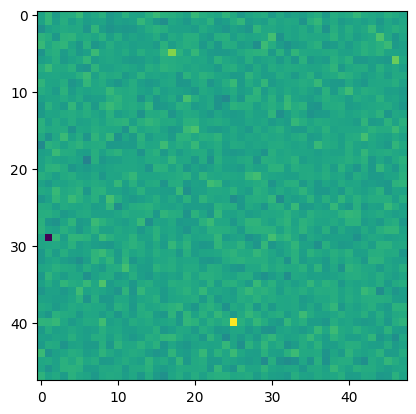

In [77]:
plt.imshow(m[0, -1, :].detach().cpu().numpy().reshape(48,48))

In [78]:
m=cache['blocks.20.hook_mlp_out.hook_sae_acts_post'].detach().cpu().numpy()
# m=cache['blocks.20.attn.hook_z.hook_sae_acts_post']
m.shape

(1, 7, 16384)

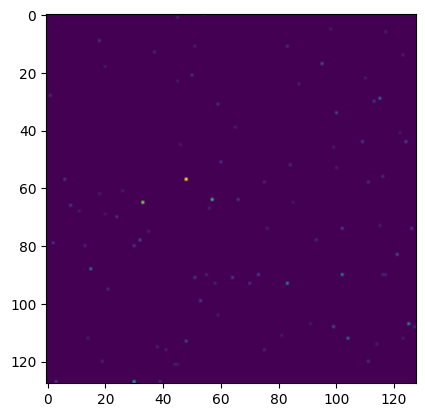

In [79]:
plt.imshow(m[0, -1, :].reshape(128,128))

In [80]:
top_indices = np.argsort(np.abs(m[0,-1]))[-10:][::-1]
m[0,-1][top_indices]

array([45.99571 , 37.25643 , 30.3834  , 23.406435, 19.71404 , 18.76269 ,
       17.087053, 15.014454, 14.425571, 13.609091], dtype=float32)

In [81]:
top_indices

array([ 7344,  8353,  8249, 16286, 13821, 11987, 11622, 11279, 14440,
        3827])

In [84]:
for act, ind in zip(*sae_acts_post.topk(5)):
    print(f"Latent {ind} had activation {act:.2f}")
    # display_dashboard(latent_idx=ind)
    display_dashboard(sae_release=gemmascope_sae_release, sae_id=gemmascope_sae_id, latent_idx=ind)

Latent 7344 had activation 46.00
https://neuronpedia.org/gemma-2-2b/20-gemmascope-mlp-16k/7344?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300


Latent 8353 had activation 37.26
https://neuronpedia.org/gemma-2-2b/20-gemmascope-mlp-16k/8353?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300


Latent 8249 had activation 30.38
https://neuronpedia.org/gemma-2-2b/20-gemmascope-mlp-16k/8249?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300


Latent 16286 had activation 23.41
https://neuronpedia.org/gemma-2-2b/20-gemmascope-mlp-16k/16286?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300


Latent 13821 had activation 19.71
https://neuronpedia.org/gemma-2-2b/20-gemmascope-mlp-16k/13821?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300


In [85]:
GENERATE_KWARGS = dict(temperature=0.5, freq_penalty=2.0, verbose=False)

In [86]:
# Test our prompt, to see what the model says
with gemma_2_2b.saes(saes=[gemma_2_2b_sae]):
    utils.test_prompt(prompt, answer, gemma_2_2b)

Tokenized prompt: ['<bos>', 'The', ' reliability', ' of', ' Wikipedia', ' is', ' very']
Tokenized answer: [' high']


Performance on answer token:
Rank: 2        Logit: 25.49 Prob: 12.46% Token: | high|

Top 0th token. Logit: 25.84 Prob: 17.56% Token: | important|
Top 1th token. Logit: 25.57 Prob: 13.51% Token: | much|
Top 2th token. Logit: 25.49 Prob: 12.46% Token: | high|
Top 3th token. Logit: 25.27 Prob: 10.01% Token: | low|
Top 4th token. Logit: 25.27 Prob:  9.98% Token: | questionable|
Top 5th token. Logit: 24.45 Prob:  4.41% Token: | poor|
Top 6th token. Logit: 24.39 Prob:  4.12% Token: | good|
Top 7th token. Logit: 23.68 Prob:  2.02% Token: | controversial|
Top 8th token. Logit: 23.57 Prob:  1.82% Token: | well|
Top 9th token. Logit: 23.27 Prob:  1.35% Token: | dependent|


Ranks of the answer tokens: [(' high', 2)]

In [87]:
latent_idx=8249

In [88]:
_steering_hook = partial(
    steering_hook,
    sae=gemma_2_2b_sae,
    latent_idx=latent_idx,
    steering_coefficient=10,
)

with gemma_2_2b.hooks(fwd_hooks=[(gemma_2_2b_sae.cfg.hook_name, _steering_hook)]):
  utils.test_prompt(prompt, answer, gemma_2_2b)

Tokenized prompt: ['<bos>', 'The', ' reliability', ' of', ' Wikipedia', ' is', ' very']
Tokenized answer: [' high']


Performance on answer token:
Rank: 3        Logit: 25.15 Prob: 10.45% Token: | high|

Top 0th token. Logit: 25.81 Prob: 20.31% Token: | important|
Top 1th token. Logit: 25.37 Prob: 13.03% Token: | much|
Top 2th token. Logit: 25.16 Prob: 10.55% Token: | questionable|
Top 3th token. Logit: 25.15 Prob: 10.45% Token: | high|
Top 4th token. Logit: 25.13 Prob: 10.26% Token: | low|
Top 5th token. Logit: 24.45 Prob:  5.16% Token: | poor|
Top 6th token. Logit: 24.23 Prob:  4.18% Token: | good|
Top 7th token. Logit: 23.50 Prob:  2.01% Token: | controversial|
Top 8th token. Logit: 23.43 Prob:  1.88% Token: | well|
Top 9th token. Logit: 23.18 Prob:  1.46% Token: | often|


Ranks of the answer tokens: [(' high', 3)]

In [89]:
_steering_hook = partial(
    steering_hook,
    sae=gemma_2_2b_sae,
    latent_idx=latent_idx,
    steering_coefficient=50,
)

with gemma_2_2b.hooks(fwd_hooks=[(gemma_2_2b_sae.cfg.hook_name, _steering_hook)]):
  utils.test_prompt(prompt, answer, gemma_2_2b)

Tokenized prompt: ['<bos>', 'The', ' reliability', ' of', ' Wikipedia', ' is', ' very']
Tokenized answer: [' high']


Performance on answer token:
Rank: 4        Logit: 24.45 Prob:  7.68% Token: | high|

Top 0th token. Logit: 25.42 Prob: 20.29% Token: | important|
Top 1th token. Logit: 25.17 Prob: 15.80% Token: | much|
Top 2th token. Logit: 25.09 Prob: 14.60% Token: | questionable|
Top 3th token. Logit: 24.47 Prob:  7.87% Token: | low|
Top 4th token. Logit: 24.45 Prob:  7.68% Token: | high|
Top 5th token. Logit: 23.77 Prob:  3.89% Token: | poor|
Top 6th token. Logit: 23.48 Prob:  2.92% Token: | good|
Top 7th token. Logit: 23.29 Prob:  2.42% Token: | controversial|
Top 8th token. Logit: 22.87 Prob:  1.59% Token: | often|
Top 9th token. Logit: 22.84 Prob:  1.54% Token: | well|


Ranks of the answer tokens: [(' high', 4)]

In [90]:
_steering_hook = partial(
    steering_hook,
    sae=gemma_2_2b_sae,
    latent_idx=latent_idx,
    steering_coefficient=100,
)

with gemma_2_2b.hooks(fwd_hooks=[(gemma_2_2b_sae.cfg.hook_name, _steering_hook)]):
  utils.test_prompt(prompt, answer, gemma_2_2b)

Tokenized prompt: ['<bos>', 'The', ' reliability', ' of', ' Wikipedia', ' is', ' very']
Tokenized answer: [' high']


Performance on answer token:
Rank: 4        Logit: 23.42 Prob:  4.76% Token: | high|

Top 0th token. Logit: 24.88 Prob: 20.61% Token: | much|
Top 1th token. Logit: 24.80 Prob: 19.01% Token: | important|
Top 2th token. Logit: 24.77 Prob: 18.35% Token: | questionable|
Top 3th token. Logit: 23.44 Prob:  4.88% Token: | low|
Top 4th token. Logit: 23.42 Prob:  4.76% Token: | high|
Top 5th token. Logit: 22.82 Prob:  2.61% Token: | controversial|
Top 6th token. Logit: 22.75 Prob:  2.44% Token: | poor|
Top 7th token. Logit: 22.46 Prob:  1.83% Token: | good|
Top 8th token. Logit: 22.42 Prob:  1.76% Token: | often|
Top 9th token. Logit: 22.29 Prob:  1.54% Token: | debatable|


Ranks of the answer tokens: [(' high', 4)]

In [91]:
_steering_hook = partial(
    steering_hook,
    sae=gemma_2_2b_sae,
    latent_idx=latent_idx,
    steering_coefficient=200,
)

with gemma_2_2b.hooks(fwd_hooks=[(gemma_2_2b_sae.cfg.hook_name, _steering_hook)]):
  utils.test_prompt(prompt, answer, gemma_2_2b)

Tokenized prompt: ['<bos>', 'The', ' reliability', ' of', ' Wikipedia', ' is', ' very']
Tokenized answer: [' high']


Performance on answer token:
Rank: 8        Logit: 21.28 Prob:  1.65% Token: | high|

Top 0th token. Logit: 24.14 Prob: 28.59% Token: | much|
Top 1th token. Logit: 23.76 Prob: 19.54% Token: | questionable|
Top 2th token. Logit: 23.39 Prob: 13.55% Token: | important|
Top 3th token. Logit: 21.69 Prob:  2.48% Token: | questioned|
Top 4th token. Logit: 21.62 Prob:  2.31% Token: | into|
Top 5th token. Logit: 21.56 Prob:  2.17% Token: | controversial|
Top 6th token. Logit: 21.41 Prob:  1.87% Token: | often|
Top 7th token. Logit: 21.38 Prob:  1.81% Token: | different|
Top 8th token. Logit: 21.28 Prob:  1.65% Token: | high|
Top 9th token. Logit: 21.24 Prob:  1.58% Token: | debatable|


Ranks of the answer tokens: [(' high', 8)]

In [92]:
_steering_hook = partial(
    steering_hook,
    sae=gemma_2_2b_sae,
    latent_idx=latent_idx,
    steering_coefficient=-100,
)

with gemma_2_2b.hooks(fwd_hooks=[(gemma_2_2b_sae.cfg.hook_name, _steering_hook)]):
  utils.test_prompt(prompt, answer, gemma_2_2b)

Tokenized prompt: ['<bos>', 'The', ' reliability', ' of', ' Wikipedia', ' is', ' very']
Tokenized answer: [' high']


Performance on answer token:
Rank: 1        Logit: 26.19 Prob: 17.30% Token: | high|

Top 0th token. Logit: 26.22 Prob: 17.80% Token: | important|
Top 1th token. Logit: 26.19 Prob: 17.30% Token: | high|
Top 2th token. Logit: 25.99 Prob: 14.15% Token: | low|
Top 3th token. Logit: 25.62 Prob:  9.78% Token: | much|
Top 4th token. Logit: 25.61 Prob:  9.71% Token: | good|
Top 5th token. Logit: 25.33 Prob:  7.32% Token: | poor|
Top 6th token. Logit: 24.24 Prob:  2.47% Token: | well|
Top 7th token. Logit: 24.10 Prob:  2.15% Token: | dependent|
Top 8th token. Logit: 23.70 Prob:  1.44% Token: | hard|
Top 9th token. Logit: 23.55 Prob:  1.24% Token: | bad|


Ranks of the answer tokens: [(' high', 1)]

### Longer Streered Generations with various streeing coefficients

In [93]:
generate_with_steering(gemma_2_2b, gemma_2_2b_sae, prompt, latent_idx, steering_coefficient=0.0)

"The reliability of Wikipedia is very much dependent on the number of users, and the number of edits that are made to any one article.\n\nI would not expect it to be reliable for anything more than a few lines, but I'd be very surprised if it wasn't"

In [94]:
generate_with_steering(gemma_2_2b, gemma_2_2b_sae, prompt, latent_idx, steering_coefficient=10.0)

'The reliability of Wikipedia is very important for the community. In this paper, we propose a method to identify unreliable sources in Wikipedia articles. We use an ensemble of classifiers that is trained on the distribution of edit history for each article and then apply it to new articles. The classifier uses'

In [95]:
generate_with_steering(gemma_2_2b, gemma_2_2b_sae, prompt, latent_idx, steering_coefficient=50.0)

'The reliability of Wikipedia is very questionable. The information is not always reliable, and can be easily changed by a single person. This has been the case with the article on the history of the United States, which was edited by one person to make it seem like it was written in'

In [96]:
generate_with_steering(gemma_2_2b, gemma_2_2b_sae, prompt, latent_idx, steering_coefficient=100.0)

'The reliability of Wikipedia is very important for the question above. I believe that it is reliable as it has over 10,000 questions and 23,467 answers. The number of questions and answers in this site may be an indicator on how reliable'

In [97]:
generate_with_steering(gemma_2_2b, gemma_2_2b_sae, prompt, latent_idx, steering_coefficient=100.0)

"The reliability of Wikipedia is very questionable. I've seen a few examples where it seems like the article was written by someone who has an agenda, and then other people have gone in to try and change it back to what it should be, but they don't know how"

In [98]:
generate_with_steering(gemma_2_2b, gemma_2_2b_sae, prompt, latent_idx, steering_coefficient=100.0)

'The reliability of Wikipedia is very important. The question is, how much?\n\nWe’re not talking about the quality of the content, but rather the question of whether Wikipedia can be trusted in a legal context. In other words, can we rely on it as a source for'

In [99]:
generate_with_steering(gemma_2_2b, gemma_2_2b_sae, prompt, latent_idx, steering_coefficient=100.0)

'The reliability of Wikipedia is very much in question. However, I think it is fair to say that the question "What are the best ways to learn programming?" has been asked many times before.\n\nOne way to learn programming is by reading books.\n\nThere are many questions on'

In [100]:
generate_with_steering(gemma_2_2b, gemma_2_2b_sae, prompt, latent_idx, steering_coefficient=500.0)

'The reliability of Wikipedia is very question into question into question into question questions questions questioned into questioned disputed questioned questioned Question questioning Question questioning Question questioning Question questionsquestion questionquestionQuestion QUESTION QUESTIONquestioninto questioningintoquestionQuestionQuestion into questioningintoQuestion questionintoquestion disputed disputed disputed questioned Into cuestion questioned'